In [6]:
# set seeds for reporducibility
import random
random.seed(0)
import numpy as np
np.random.seed(0)
import tensorflow as tf
tf.random.set_seed(0)





Importing the Dependencies

In [10]:
import os

In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

In [4]:
 # Data loading and preprocessing
!pip install -q kaggle

In [5]:
!kaggle datasets download -d abdallahalidev/plantvillage-dataset

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [00:14<00:00, 151MB/s]



In [7]:

!ls

plantvillage-dataset.zip  sample_data


In [8]:
# Unzip the downloaded dataset
with ZipFile("plantvillage-dataset.zip", 'r') as zip_ref:
    zip_ref.extractall()

In [9]:
print(os.listdir("plantvillage dataset"))

['color', 'grayscale', 'segmented']


(256, 256, 3)


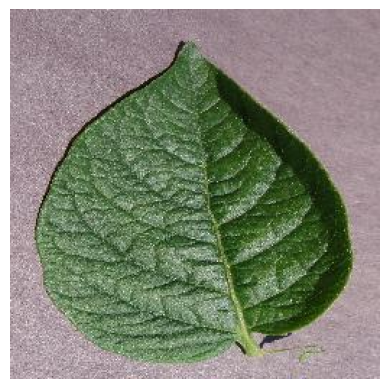

In [11]:
image_path = '/content/plantvillage dataset/color/Potato___healthy/03da9931-e514-4cc7-b04a-8f474a133ce5___RS_HL 1830.JPG'

# Read the image
img = mpimg.imread(image_path)

print(img.shape)
# Display the image
plt.imshow(img)
plt.axis('off')  # Turn off axis numbers
plt.show()

In [13]:
# Image Parameters
img_size = 224
batch_size = 32

Train Test Split

In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [15]:
base_dir = 'plantvillage dataset/color'

image_paths = []
labels = []

for class_name in os.listdir(base_dir):
    class_folder_path = os.path.join(base_dir, class_name)
    if os.path.isdir(class_folder_path):
        for image_name in os.listdir(class_folder_path):
            image_full_path = os.path.join(class_folder_path, image_name)
            image_paths.append(image_full_path)
            labels.append(class_name)

# Create a DataFrame
df = pd.DataFrame({'path': image_paths, 'label': labels})

In [18]:
df.head()

,path,label
0,plantvillage dataset/color/Tomato___Leaf_Mold/...,Tomato___Leaf_Mold
1,plantvillage dataset/color/Tomato___Leaf_Mold/...,Tomato___Leaf_Mold
2,plantvillage dataset/color/Tomato___Leaf_Mold/...,Tomato___Leaf_Mold
3,plantvillage dataset/color/Tomato___Leaf_Mold/...,Tomato___Leaf_Mold
4,plantvillage dataset/color/Tomato___Leaf_Mold/...,Tomato___Leaf_Mold


In [16]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42

)



CNN and ANN

In [19]:
# Image Data Generators
train_datagen = ImageDataGenerator( rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2)
validation_datagen = ImageDataGenerator( rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2)

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='path',
    y_col='label',
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)

validation_generator = validation_datagen.flow_from_dataframe(
    val_df,
    x_col='path',
    y_col='label',
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)

Found 43444 validated image filenames belonging to 38 classes.
Found 10861 validated image filenames belonging to 38 classes.


In [23]:
from tensorflow.keras import models, layers

model = models.Sequential()

# Block 1
model.add(
    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(img_size, img_size, 3)
    )
)
model.add(layers.MaxPooling2D(2,2))

# Block 2
model.add(
    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)
model.add(layers.MaxPooling2D(2,2))

# Block 3
model.add(
    layers.Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)
model.add(layers.MaxPooling2D(2,2))

# Classifier
model.add(layers.Flatten())

model.add(
    layers.Dense(
        256,
        activation='relu'
    )
)

model.add(
    layers.Dropout(0.5)
)

model.add(
    layers.Dense(
        num_classes,
        activation='softmax'
    )
)

In [24]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,254,438 (84.89 MB)

 Trainable params: 22,254,438 (84.89 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Compile the Model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [28]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [30]:
# Training the Model
history = model.fit(
    train_generator,
    epochs=5,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size,
    callbacks=[early_stop]
)

Epoch 1/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 692s 510ms/step - accuracy: 0.5046 - loss: 1.7328 - val_accuracy: 0.6792 - val_loss: 1.0727
Epoch 2/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 685s 504ms/step - accuracy: 0.6570 - loss: 1.1375 - val_accuracy: 0.7553 - val_loss: 0.7714
Epoch 3/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 686s 505ms/step - accuracy: 0.7205 - loss: 0.9149 - val_accuracy: 0.8242 - val_loss: 0.5735
Epoch 4/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 692s 510ms/step - accuracy: 0.7583 - loss: 0.7793 - val_accuracy: 0.7881 - val_loss: 0.6645
Epoch 5/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 693s 510ms/step - accuracy: 0.7877 - loss: 0.6810 - val_accuracy: 0.8428 - val_loss: 0.4777


In [31]:
# model evalution
val_loss, val_acc = model.evaluate(validation_generator)
print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_acc)

340/340 ━━━━━━━━━━━━━━━━━━━━ 133s 391ms/step - accuracy: 0.8454 - loss: 0.4764
Validation Loss: 0.4764268696308136
Validation Accuracy: 0.845410168170929


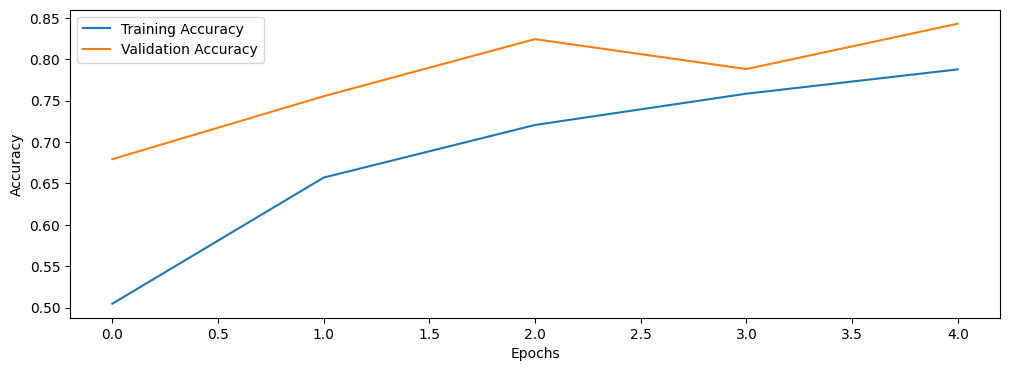

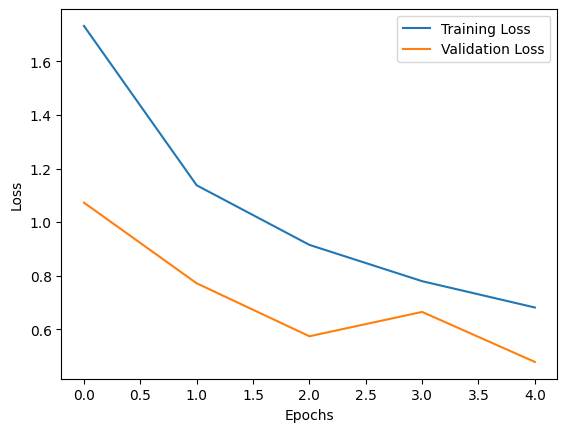

In [32]:
#  plot  accuracy vs val accuracy and loss vs val loss
plt.figure(figsize=(12, 4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [33]:
# prediciting model
# load and process the image using pillow
def load_and_preprocess_image(image_path, target_size=(img_size, img_size)):
    # Load the image
    img = Image.open(image_path)
    # Resize the image
    img = img.resize(target_size)
    # Convert to numpy array
    img_array = np.array(img)
    # Normalize pixel values (scale to 0-1)
    img_array = img_array / 255.0
    # Add batch dimension (model expects a batch of images)
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

In [34]:
# function to predict the class of image
def predict_image_class(model,image_path,class_indices):
    img_array = load_and_preprocess_image(image_path)
    prediction = model.predict(img_array)
    predicted_class_index = np.argmax(prediction)
    predicted_class = list(class_indices.keys())[list(class_indices.values()).index(predicted_class_index)]
    return predicted_class


In [35]:
# create a mapping from class indices to classames
class_indices = train_generator.class_indices

In [36]:
class_indices

{'Apple___Apple_scab': 0,
 'Apple___Black_rot': 1,
 'Apple___Cedar_apple_rust': 2,
 'Apple___healthy': 3,
 'Blueberry___healthy': 4,
 'Cherry_(including_sour)___Powdery_mildew': 5,
 'Cherry_(including_sour)___healthy': 6,
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7,
 'Corn_(maize)___Common_rust_': 8,
 'Corn_(maize)___Northern_Leaf_Blight': 9,
 'Corn_(maize)___healthy': 10,
 'Grape___Black_rot': 11,
 'Grape___Esca_(Black_Measles)': 12,
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13,
 'Grape___healthy': 14,
 'Orange___Haunglongbing_(Citrus_greening)': 15,
 'Peach___Bacterial_spot': 16,
 'Peach___healthy': 17,
 'Pepper,_bell___Bacterial_spot': 18,
 'Pepper,_bell___healthy': 19,
 'Potato___Early_blight': 20,
 'Potato___Late_blight': 21,
 'Potato___healthy': 22,
 'Raspberry___healthy': 23,
 'Soybean___healthy': 24,
 'Squash___Powdery_mildew': 25,
 'Strawberry___Leaf_scorch': 26,
 'Strawberry___healthy': 27,
 'Tomato___Bacterial_spot': 28,
 'Tomato___Early_blight': 29,
 'Toma

In [37]:
# example usage

# Path to the image file to predict
#image_path = '/content/powdery-mildew-powdery-mildew-on-squash-leaf-shutterstock-com_13365.webp'
#image_path='/content/plantvillage dataset/color/Cherry_(including_sour)___Powdery_mildew/0325a93a-4fa1-4eae-a6a9-fc6baa82ca7f___FREC_Pwd.M 0434.JPG'
image_path='/content/plantvillage dataset/color/Cherry_(including_sour)___Powdery_mildew/012b55cf-de7a-483a-9118-0fd8ff012185___FREC_Pwd.M 0423.JPG'
# Check if the image file exists
if os.path.exists(image_path) and os.path.isfile(image_path):
    predicted_class = predict_image_class(model, image_path, class_indices)
    print("Predicted Class:", predicted_class)
else:
    print(f"Image file not found at {image_path}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 881ms/step
Predicted Class: Cherry_(including_sour)___Powdery_mildew


In [38]:
# saving the class names as json file
json.dump(class_indices, open('class_indices.json', 'w'))

In [39]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)



Mounted at /content/drive


In [40]:

model.save('drive/MyDrive/Youtube/trained_models/plant_disease_prediction_model.h5')

In [41]:
import tensorflow as tf

print(tf.__version__)

2.20.0
